# Data Quality Checks

Quick QC before trusting a chunk's results:
- Does the RF mosaic look like a real, well-separated set of cells (not noise)?
- Does each cell type's RF time course look clean (biphasic, not flat/noisy)?
- Are cells actually responding during the noise stimulus (spike counts)?
- Does each cell's EI footprint look like the *same* cell when matched across light
  levels (NDFs) -- not just that `cluster_match()`'s correlation cleared a threshold?

Assumes the database is already populated (run `1_database_demo.ipynb` first if it
isn't) -- this notebook just searches for datasets, picks one, and runs QC on it.


Import `retinanalysis` and the standard scientific-Python packages this notebook uses.

In [1]:
import retinanalysis as ra
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os

C:\Users\Yasmine Tani\anaconda3\envs\retinanalysis\Lib\site-packages\datajoint\settings.py:992: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


Works around a real bug found in visionloader's compiled double-array field parser (used for RF timecourses, among other fields) -- see `changes/` for details. Safe to run even if your data isn't affected; must run before any pipeline/AnalysisChunk is built below.

In [2]:
ra.patch_vision_double_array_bug()


Patched visionloader's double-array '.params' field parsing (timecourses, etc.) to use a pure-Python fallback instead of the buggy compiled extension.


## Search for datasets

Searches the database for every SpatialNoise-protocol dataset, then filters to experiments that actually have local analysis files available on this machine.

In [3]:
exp_search = ra.get_datasets_from_protocol_names('spatialnoise')
available_experiments = os.listdir(ra.ANALYSIS_DIR)
exp_search = exp_search.query('exp_name in @available_experiments').reset_index(drop = True)
ra.scrollable_dataframe(exp_search)

[2026-08-19 16:24:57] DataJoint 2.2.2 connected to root@127.0.0.1:3306

Found 2 protocols matching "spatialnoise":
['fieldlab.protocols.SpatialNoise_ks' 'manookinlab.protocols.SpatialNoise']

Found 39 experiments, 158 epoch blocks.



,exp_name,datafile_name,NDF,chunk_name,protocol_name,is_mea,data_dir,group_label,experiment_id,protocol_id,group_id,block_id,chunk_id
0,20240820A,data000,NaN,data000,manookinlab.protocols.SpatialNoise,1,20240820A\data000,noise,385,1,1388,4081,3685
1,20240820A,data002,NaN,data002,manookinlab.protocols.SpatialNoise,1,20240820A\data002,noise,385,1,1390,4083,3687
2,20240820A,data003,NaN,data003,manookinlab.protocols.SpatialNoise,1,20240820A\data003,Control,385,1,1391,4084,3688
3,20240820A,data004,NaN,data004,manookinlab.protocols.SpatialNoise,1,20240820A\data004,Control,385,1,1392,4085,3689
4,20240820A,data005,NaN,data005,manookinlab.protocols.SpatialNoise,1,20240820A\data005,Control,385,1,1392,4086,3690
5,20240820A,data006,NaN,data006,manookinlab.protocols.SpatialNoise,1,20240820A\data006,Control,385,1,1392,4087,3691
6,20240820A,data007,NaN,data007,manookinlab.protocols.SpatialNoise,1,20240820A\data007,Control,385,1,1392,4088,3692
7,20240820A,data008,NaN,data008,manookinlab.protocols.SpatialNoise,1,20240820A\data008,Control,385,1,1392,4089,3693
8,20240820A,data009,NaN,data009,manookinlab.protocols.SpatialNoise,1,20240820A\data009,Control,385,1,1392,4090,3694
9,20240820A,data010,NaN,data010,manookinlab.protocols.SpatialNoise,1,20240820A\data010,Control,385,1,1393,4091,3695


## Cell types to check

`None` (default) auto-detects every cell type in this chunk's classification file; the RF/timecourse/spike-count cells below all use this. Set to a specific list (e.g. `['on/brisk sustained']`) to restrict the QC checks instead.

In [4]:
cell_types = None  # e.g. ['on/brisk sustained'] to restrict -- None plots every type present


## Choose an Experiment

Pick which experiment to analyze and its SpatialNoise datafile (auto-picks the earliest if there are several).

In [5]:
exp_name = '20260506A'
datafile_name = ra.find_datafile_for_protocol(exp_search, exp_name)

experiment_summary = ra.get_exp_summary(exp_name)
display(experiment_summary.head())


20260506A: 9 matching datafiles found: ['data000', 'data001', 'data003', 'data004', 'data006', 'data007', 'data009', 'data010', 'data011']. Using the earliest, data000. Pass a different datafile_name directly if you want a different one.


,exp_name,prep_label,datafile_name,group_label,NDF,chunk_name,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,data_dir,experiment_id,prep_id,group_id,block_id,chunk_id,protocol_id
0,20260506A,mount1,data000,NDF 4.0,4.0,data000,manookinlab.protocols.SpatialNoise,30.20,30.20,2026-05-06 13:02:28,2026-05-06 13:32:40,20260506A\data000,441,440,1607,4730,4092,1
1,20260506A,mount1,data001,NDF 4.0,4.0,data001,manookinlab.protocols.SpatialNoise,30.25,65.25,2026-05-06 13:37:28,2026-05-06 14:07:43,20260506A\data001,441,440,1607,4731,4093,1
2,20260506A,mount1,data002,NDF 4.0,4.0,data002,manookinlab.protocols.PresentImages,18.22,140.93,2026-05-06 15:05:11,2026-05-06 15:23:24,20260506A\data002,441,440,1607,4732,4094,10
3,20260506A,mount1,data003,NDF 3.0,3.0,data003,manookinlab.protocols.SpatialNoise,30.23,187.62,2026-05-06 15:39:51,2026-05-06 16:10:05,20260506A\data003,441,440,1608,4733,4095,1
4,20260506A,mount1,data004,NDF 3.0,3.0,data004,manookinlab.protocols.SpatialNoise,30.23,229.08,2026-05-06 16:21:19,2026-05-06 16:51:33,20260506A\data004,441,440,1608,4734,4096,1


## Picking of Classification File for Cell Typing

Builds the MEA pipeline for this datafile, auto-picking a classified white-noise chunk for cell typing unless you set `MANUAL_ANALYSIS_CHUNK`.

In [6]:
PREFERRED_TYPING_FILE = None  # e.g. 'data007.classificationYT.txt' -- None auto-picks the first one found
MANUAL_ANALYSIS_CHUNK = None  # e.g. 'data001' -- set to skip auto-detection

analysis_chunk_name = MANUAL_ANALYSIS_CHUNK or ra.find_classified_noise_chunk(exp_name)

with ra.scrollable_prints():
    pipeline = ra.create_mea_pipeline(
        exp_name, datafile_name, analysis_chunk_name=analysis_chunk_name, typing_file=PREFERRED_TYPING_FILE,
    )


20260506A: 5 classified chunks found at NDF 0: ['data006', 'data007', 'data009', 'data010', 'data011']. Using the earliest, data006 (classification file(s): ['data006.classificationYT.txt']). Pass a different chunk name as analysis_chunk_name= to create_mea_pipeline if you want a different one.
  Stimulus parameters for data006:
    NDF: 0.0
    alpha: 1.0
    amp: Amp1
    amp2: (None)
    appVersion: None
    backgroundIntensity: 0.5
    canvasSize: [1824.0, 1140.0]
    centerOffset: [0.0, 0.0]
    chromaticClass: achromatic
    contrast: 1.0
    dataFileName: 20260506A\data006.bin
    dspVersion: None
    expectedRefreshRate: 59.94
    externalCommandSensitivity: 0.02
    externalCommandSensitivityUnits: V_V
    filterSdStixels: 1.0
    firmwareVersion: None
    frameDwell: 4.0
    frameDwells: [4.0, 4.0]
    frameRate: 59.0
    gaussianFilter: 0
    gridSize: 25.0
    hardwareType: MCTG_HW_TYPE_MC700B
    interpulseInterval: 0.5
    lightCrafterLedCurrents: [104.0, 135.0, 130.0]
  

## Break Out Underlying Objects

Splits the pipeline into its stimulus, response, and analysis-chunk objects for direct use below.

In [7]:
stim_block = pipeline.stim
response_block = pipeline.resp
analysis_chunk = pipeline.analysis_chunk

## Pull Epoch Block Parameters

Per-block stimulus parameters (needed below for the spike-count baseline window).


In [8]:
epoch_block_params = stim_block.d_epoch_block_params


## Pull Spike Times and Spike Counts

Extracts per-cell spike times/counts for the chosen cell types, plus a baseline (pre-stimulus) spike count for comparison.

In [9]:
spike_times = ra.get_spike_xarr(response_block, cell_types = cell_types, minimum_n = 3)
spike_counts = xr.apply_ufunc(len, spike_times, vectorize = True)

def get_avg_baseline(arr, pre_time):
    pre_spikes = [spike for spike in arr if spike < pre_time]
    return len(pre_spikes)

pre_time = epoch_block_params['preTime']
baseline_spike_counts = xr.apply_ufunc(get_avg_baseline, spike_times,
                                       kwargs = {'pre_time' : pre_time},
                                       vectorize = True)


## Plot Noise RFs and Cluster Matched RFs to Compare

First, a quick count of cells per classification label; then each cell type's RF mosaic from both the protocol's own sort and the reference noise chunk, for comparison.

In [10]:
pipeline.analysis_chunk.df_cell_params['typing_file_0'].value_counts()

typing_file_0
Unknown                285
off/brisk sustained     25
on/brisk sustained      22
on/brisk transient      11
off/brisk transient     10
Name: count, dtype: int64

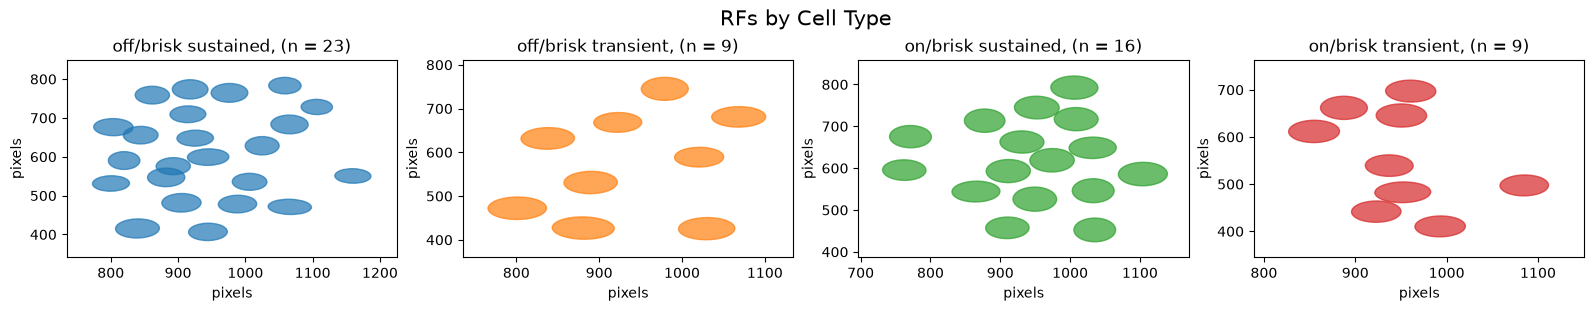

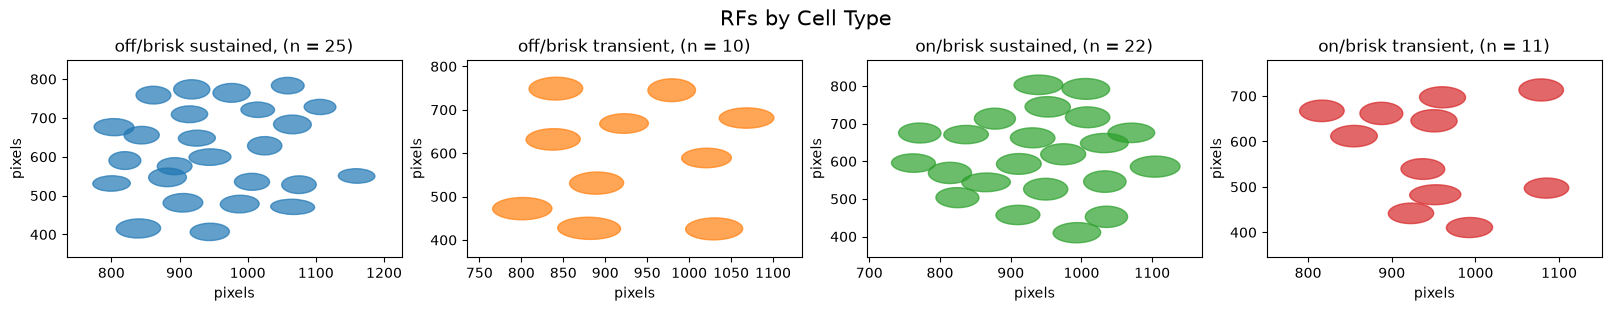

In [11]:
protocol_rfs = pipeline.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True)
noise_rfs = pipeline.analysis_chunk.plot_rfs(cell_types = cell_types, minimum_n = 3, b_zoom = True,
                                             typing_file = PREFERRED_TYPING_FILE)


### Receptive Field Portraits (raw pixels per cell)

Alternative to the fitted-ellipse mosaic above: crops each cell's own raw spatial STA
pixels to a small window around its RF center, polarity-corrects and normalizes them,
and tiles them into a grid -- closer to the lab's MATLAB `plot_rf_portraits.m` style.
Useful for spotting individual noisy or broken RFs that a fitted ellipse can hide.

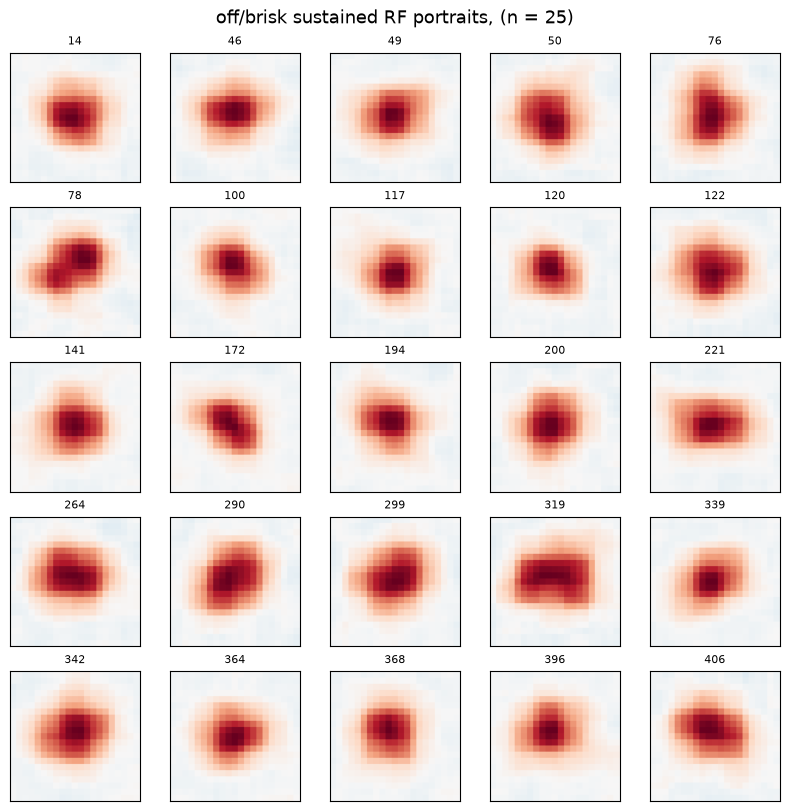

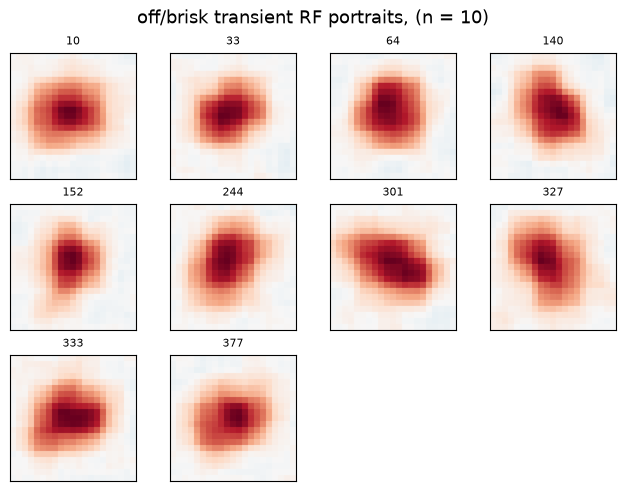

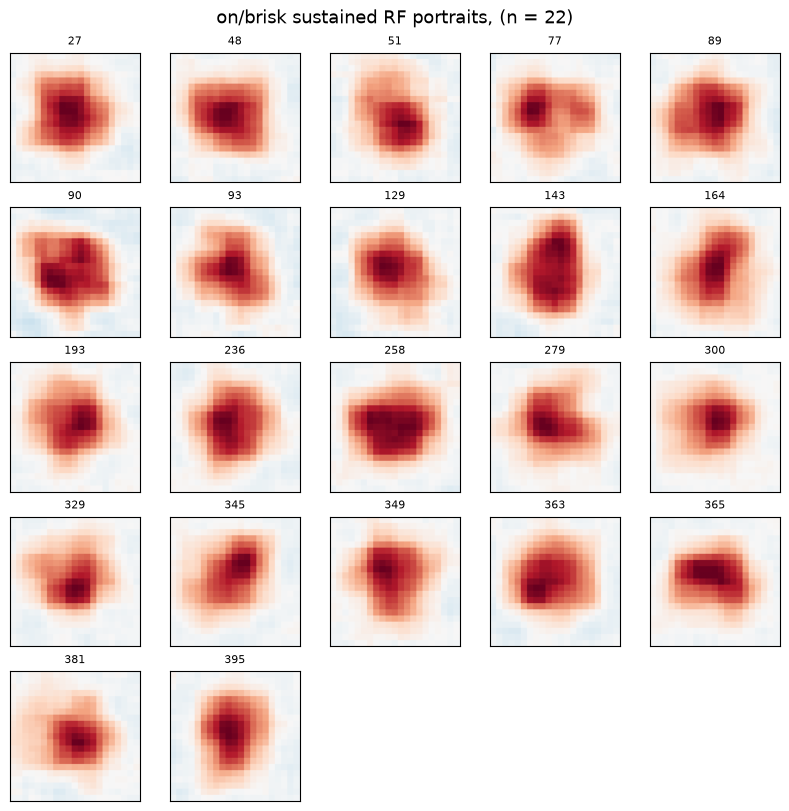

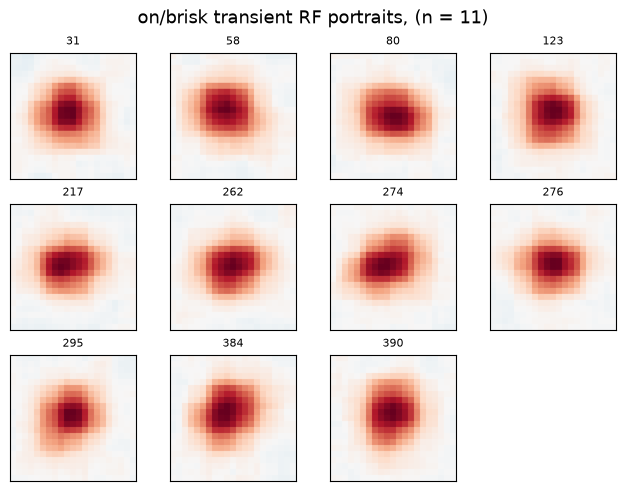

In [12]:
PLOT_RADIUS = 10  # half-width, in stixels, of the cropped window around each cell's RF center

noise_rf_portraits = pipeline.analysis_chunk.plot_rf_portraits(
    cell_types = cell_types, minimum_n = 3, plot_radius = PLOT_RADIUS,
    typing_file = PREFERRED_TYPING_FILE,
)
# for cell_type, f in noise_rf_portraits.items():
#     f.savefig(f'{exp_name}_{cell_type}_rf_portraits.png', dpi=300, bbox_inches='tight')  # uncomment to save


## Receptive Field Time Courses

Mean +/- SD time course per cell type (red/green/blue, from each cell's STA), same
cell-type/minimum_n filtering as the RF mosaic above. A cell type with a noisy,
non-biphasic, or flat time course here is a red flag even if its RF mosaic above
looked fine spatially -- these two checks catch different failure modes.


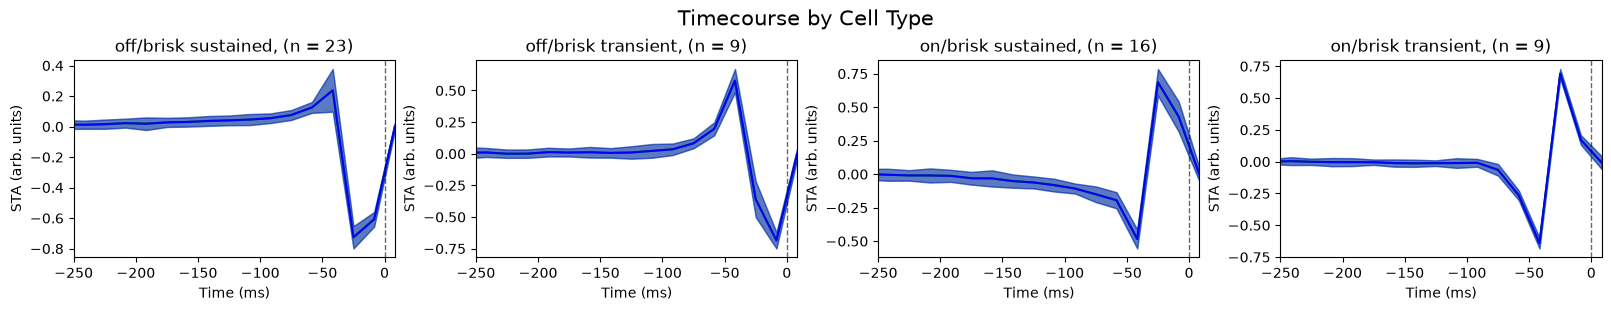

In [13]:
noise_timecourses = pipeline.plot_timecourses(cell_types = cell_types, minimum_n = 3)


## Spike Count Summary (quick QC check that cells are responding)

Per-cell-type spike count summary for this block -- a quick sanity check that cells
are actually firing during the noise stimulus, before trusting anything downstream.


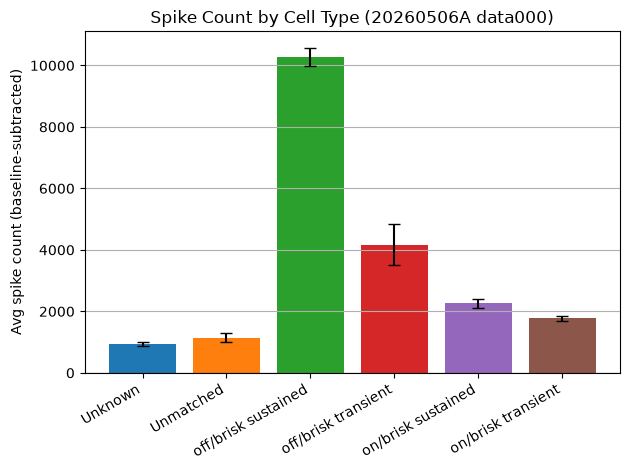

In [14]:
cell_types = sorted(np.unique(spike_times.coords['cell_type'].values))

means = []
sems = []
for ct in cell_types:
    ct_counts = spike_counts.where(spike_counts.cell_type == ct, drop = True)
    ct_baseline = baseline_spike_counts.where(baseline_spike_counts.cell_type == ct, drop = True)
    baseline_mean = ct_baseline.mean(dim = ['cell_id', 'epoch'], skipna = True).item()
    per_cell_mean = ct_counts.mean(dim = 'epoch', skipna = True) - baseline_mean
    n_cells = int(per_cell_mean.count(dim = 'cell_id'))
    means.append(per_cell_mean.mean(dim = 'cell_id', skipna = True).item())
    sems.append(per_cell_mean.std(dim = 'cell_id', skipna = True).item() / np.sqrt(max(n_cells, 1)))

fig, ax = plt.subplots()
x = np.arange(len(cell_types))
ax.bar(x, means, yerr = sems, capsize = 4, color = [f'C{i}' for i in range(len(cell_types))])
ax.axhline(0, color = 'k', linewidth = 0.8)
ax.set_xticks(x)
ax.set_xticklabels(cell_types, rotation = 30, ha = 'right')
ax.set_title(f'Spike Count by Cell Type ({exp_name} {datafile_name})')
ax.set_ylabel('Avg spike count (baseline-subtracted)')
ax.grid(True, axis = 'y')
fig.tight_layout()


---
## Data Quality: EI Footprint Across Light Levels

Checks that the reference chunk's cells track consistently across NDFs -- for one example cell, shows its EI footprint at the reference chunk plus its EI-matched counterpart at every other NDF this protocol was run at. Uses the existing `cluster_match()`/`ei_corr()` matching convention.


In [ ]:
CELL_ID_TO_CHECK = None  # set to a specific cell_id in analysis_chunk.cell_ids to check that cell instead of auto-picking one

df_ei_matches, ndf_vcds, ref_ndf = ra.get_ei_matches_across_ndfs(
    analysis_chunk, exp_name, analysis_chunk.noise_protocol, ss_version=analysis_chunk.ss_version,
)

if len(df_ei_matches) == 0:
    print('No EI matches found against any other NDF for this protocol -- nothing to check.')
else:
    ei_match_summary = ra.summarize_ei_matches(df_ei_matches)
    print(f'{len(ei_match_summary)} ref cell(s) matched at >=1 other NDF (of {len(ndf_vcds)} other NDF(s) found). '
          f'Reference chunk ({analysis_chunk.chunk_name}) is at NDF {ref_ndf}.')
    print('Ranked best-to-worst -- pick a ref_cell_id from the table below, set CELL_ID_TO_CHECK to it, '
          'then just re-run the next cell (no need to re-run this one).')
    display(ei_match_summary.head(20))

20260506A: 5 'manookinlab.protocols.SpatialNoise' blocks found at NDF 0.0: ['data006', 'data007', 'data009', 'data010', 'data011']. Using the earliest, data006.
20260506A: 2 'manookinlab.protocols.SpatialNoise' blocks found at NDF 3.0: ['data003', 'data004']. Using the earliest, data003.
20260506A: 2 'manookinlab.protocols.SpatialNoise' blocks found at NDF 4.0: ['data000', 'data001']. Using the earliest, data000.
20260506A: found 3 NDF level(s) for 'manookinlab.protocols.SpatialNoise': [0.0, 3.0, 4.0]
--- NDF 0.0 (data006) is the reference chunk's own datafile, skipping (matching it against itself is trivial) ---
--- NDF 3.0 (data003) ---
Initializing ResponseBlock for 20260506A block 4733
Keeping only 9 epochs.
Assuming n_epochs = 9
Loading VCD from B:\Array-data\sorted\20260506A\kilosort25\data003 ...


### EI footprint mosaic: one cell type across NDFs, scrollable

Same footprint-across-NDFs comparison as the cell above, but one row per cell of a chosen type instead of a single cell, so a whole type can be scanned for outliers. Reuses `df_ei_matches`/`ndf_vcds` already computed above -- no re-matching.

In [ ]:
EI_MOSAIC_NDF_VALUES = None  # e.g. [5.0, 4.0] -- None uses every NDF in ndf_vcds (printed below)
EI_MOSAIC_CELL_TYPE = None  # e.g. 'off/brisk transient' -- None picks the first real (non-Unknown/Unmatched) type

if not ndf_vcds:
    print('No NDF data loaded (see the cell above) -- nothing to make a mosaic of.')
else:
    _typing_file_mosaic = next(
        (f for f in analysis_chunk.typing_files if 'classification' in f.lower()),
        analysis_chunk.typing_files[0],
    )
    _col_idx_mosaic = analysis_chunk.typing_files.index(_typing_file_mosaic)
    _available_types_mosaic = sorted(analysis_chunk.df_cell_params[f'typing_file_{_col_idx_mosaic}'].unique())
    _real_types_mosaic = [t for t in _available_types_mosaic if t not in ('Unknown', 'Unmatched')]
    ei_mosaic_cell_type = EI_MOSAIC_CELL_TYPE or (_real_types_mosaic[0] if _real_types_mosaic else _available_types_mosaic[0])
    print(f'EI footprint mosaic: cell type {ei_mosaic_cell_type!r}, NDF(s) {EI_MOSAIC_NDF_VALUES or sorted(ndf_vcds.keys(), reverse=True)} '
          f'+ reference (NDF {ref_ndf}) (available NDFs: {sorted(ndf_vcds.keys())}; available types: {_available_types_mosaic})')

    fig_ei_mosaic = ra.plot_ei_footprint_mosaic_for_cell_type(
        analysis_chunk, df_ei_matches, ndf_vcds, ei_mosaic_cell_type,
        ndf_values=EI_MOSAIC_NDF_VALUES, ref_ndf=ref_ndf, typing_file=_typing_file_mosaic,
    )
    ra.scrollable_figure(fig_ei_mosaic, max_height_px=600)
